<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week4_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [4]:

#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [5]:
#Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

model = LogisticRegression(max_iter = 5000, random_state = 42)
model.fit(X_train_scaled, y_train)

#Prediction
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

#Evaluation
accuracy_score = accuracy_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred)
recall_score = recall_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
roc_auc_score = roc_auc_score(y_test, y_pred)
print("Accuracy:",accuracy_score)
print("Precision:",precision_score)
print("Recall:", recall_score)
print("F1 score:", f1_score)
print("ROC AUC: ", roc_auc_score)


cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)


Accuracy: 0.9790209790209791
Precision: 0.9886363636363636
Recall: 0.9775280898876404
F1 score: 0.9830508474576272
ROC AUC:  0.9795047856845609

Confusion Matrix: 
 [[53  1]
 [ 2 87]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



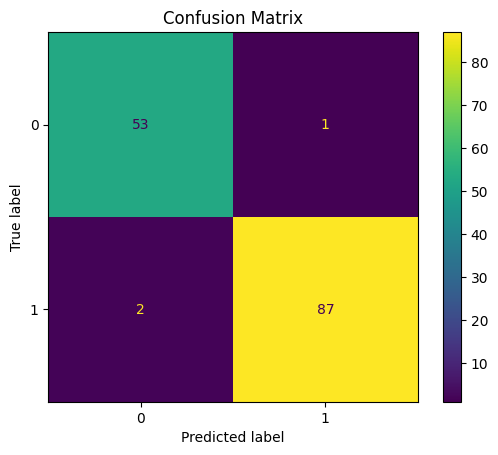

In [6]:
#Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.show()



               Feature  Coefficient
21            texture3    -1.302299
10             radius2    -1.286492
28           symmetry3    -1.226697
7      concave_points1    -1.088011
26          concavity3    -1.006375
13               area2    -0.895123
20             radius3    -0.846302
23               area3    -0.822258
27     concave_points3    -0.775197
6           concavity1    -0.735499
19  fractal_dimension2     0.729363
15        compactness2     0.636886
5         compactness1     0.617008
12          perimeter2    -0.592756
24         smoothness3    -0.530838


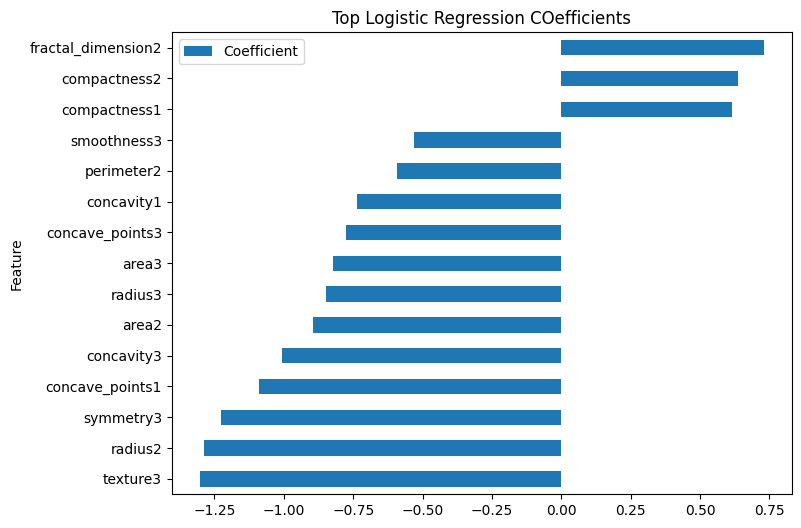

In [7]:
#Feature Impotance
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False)
print(coef_df.head(15))

coef_df.head(15).sort_values("Coefficient").plot(x="Feature", y="Coefficient", kind="barh", figsize=(8,6))
plt.title("Top Logistic Regression COefficients")
plt.show()


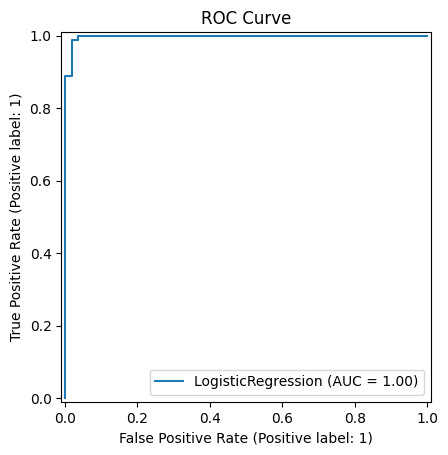

In [8]:
#ROC curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve")
plt.show()


In [9]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#-------------------------------------------------------
# Feature Scaling
#-------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-------------------------------------------------------
# 5-Fold Cross Validation Setup
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=5000, random_state=42)

cv_scores = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
)

#-------------------------------------------------------
# CV Results
#-------------------------------------------------------

print("5-Fold Cross Validation Results (Logistic Regression)")
print("-----------------------------------------------------")

print("Accuracy :", cv_scores['test_accuracy'].mean())
print("Precision:", cv_scores['test_precision'].mean())
print("Recall   :", cv_scores['test_recall'].mean())
print("F1 Score :", cv_scores['test_f1'].mean())
print("ROC AUC  :", cv_scores['test_roc_auc'].mean())

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#-------------------------------------------------------
# Test Evaluation
#-------------------------------------------------------

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nTest Set Results")
print("----------------")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

#-------------------------------------------------------
# Confusion Matrix + Report
#-------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n\n", cr)

5-Fold Cross Validation Results (Logistic Regression)
-----------------------------------------------------
Accuracy : 0.9764705882352942
Precision: 0.9705863599677158
Recall   : 0.9919871794871795
F1 Score : 0.9809926184926185
ROC AUC  : 0.9939147082004226

Test Set Results
----------------
Accuracy : 0.9790209790209791
Precision: 0.9886363636363636
Recall   : 0.9775280898876404
F1 Score : 0.9830508474576272
ROC AUC  : 0.9977111943404079

Confusion Matrix:
 [[53  1]
 [ 2 87]]

Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



               Feature  Coefficient  Abs_Coeff
21            texture3    -1.302299   1.302299
10             radius2    -1.286492   1.286492
28           symmetry3    -1.226697   1.226697
7      concave_points1    -1.088011   1.088011
26          concavity3    -1.006375   1.006375
13               area2    -0.895123   0.895123
20             radius3    -0.846302   0.846302
23               area3    -0.822258   0.822258
27     concave_points3    -0.775197   0.775197
6           concavity1    -0.735499   0.735499
19  fractal_dimension2     0.729363   0.729363
15        compactness2     0.636886   0.636886
5         compactness1     0.617008   0.617008
12          perimeter2    -0.592756   0.592756
24         smoothness3    -0.530838   0.530838


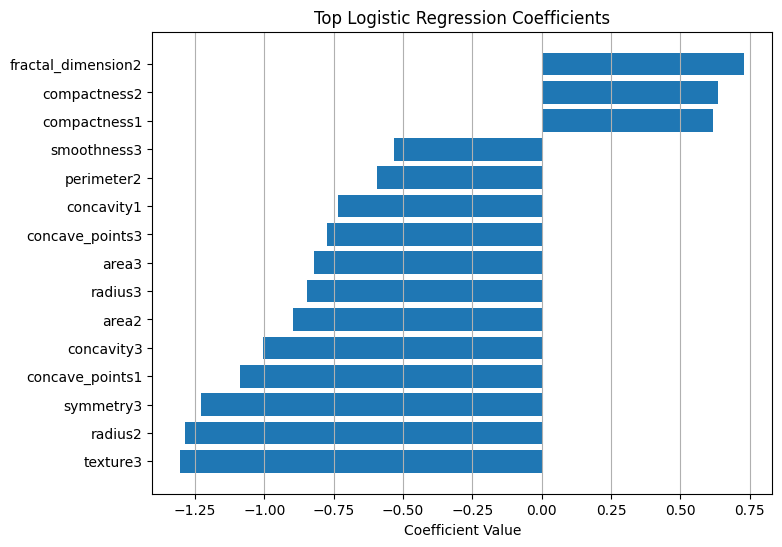

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

#-------------------------------------------------------
# Feature importance (Logistic Regression coefficients)
#-------------------------------------------------------

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by absolute importance
coef_df["Abs_Coeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coeff", ascending=False)

print(coef_df.head(15))

#-------------------------------------------------------
# Plot Top 15 Features
#-------------------------------------------------------

top_features = coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.grid(axis='x')

plt.show()